# Exercise 01: Exploring and Analyzing Protein Structures in the PDB Database

## Learning Objectives

In this exercise, you will learn to:
- Query the PDB database programmatically
- Extract and analyze structural quality metrics
- **Critically evaluate** data quality and make informed decisions
- **Interpret** structural data in biological context
- Use a multiple sequence alignment to find conserved regions and relate them to structure

## Using AI Tools

You may use AI assistants (ChatGPT, Claude, etc.) for:
- Understanding syntax and library functions
- Debugging code errors
- Generating code snippets

However, **you must demonstrate**:
- Your own biological reasoning and interpretation
- Justification for decisions (not just "AI said so")
- Critical evaluation of results

**The exercise assesses your understanding and judgment, not code generation.**

**Time budget: about 45 minutes** for this guide, read and run. The workbook that follows
is roughly another 45 to 60 minutes on your own protein.

## What you will not learn here

- How to **predict** a structure. That is Day 2 and ex02.
- How to **simulate** one. Day 3 and ex03.
- How to **dock** a ligand into one. Day 4 and ex04.
- Crystallographic refinement itself. You will read quality metrics, not produce them.

**Exercise 01 is two notebooks:**

| Notebook | What it is |
|---|---|
| **`ex01_guide.ipynb`** (this one) | A fully worked walkthrough on one protein, 1FSZ. Every cell is filled in and explained. Nothing here is graded — read it, run it, and use it as your reference. |
| **`ex01_workbook.ipynb`** | The graded notebook. Open it once you have finished here. |

## Introduction and Basic Skills

We'll start by learning how to query PDB and extract structural information, using one
real protein — FtsZ, PDB entry **1FSZ** — end to end.

In [1]:
# Check if running on Google Colab
try:
    from google.colab import drive  # noqa: F401  (import is the availability test)
    is_google_colab = True
except ImportError:
    is_google_colab = False

# If on Google Colab, install the package
if is_google_colab:
    %pip install numpy==2.1.3 scipy==1.16.3 pandas==2.2.3 biopandas==0.4.1 py3dmol==2.4.0 biopython==1.85 pyfamsa==0.7.0 pymsaviz==0.5.0

# NOTE: Ignore specific warning message from ipykernel=5.5.6
import warnings
import os

In [2]:
# Import libraries
import gzip
import io
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from biopandas.pdb import PandasPdb
from Bio import SeqIO
from Bio.Align import MultipleSeqAlignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from pyfamsa import Aligner, Sequence
from pymsaviz import MsaViz
import py3Dmol


# Suppress all warnings at the Python level
warnings.filterwarnings('ignore')

# Also set environment variable to suppress warnings
os.environ['PYTHONWARNINGS'] = 'ignore'

# pandas draws through matplotlib by default -- df.plot() gives us a real Axes back,
# which keeps most plots in this notebook to two or three lines.
print("All libraries loaded successfully")

All libraries loaded successfully


### Meet FtsZ, and our anchor structure: 1FSZ

**FtsZ** drives bacterial and archaeal cell division: it self-assembles into a contractile
ring at the division site and constricts to split the cell. It is a GTPase and a structural
homolog of eukaryotic **tubulin**, which makes it an attractive antibacterial target.

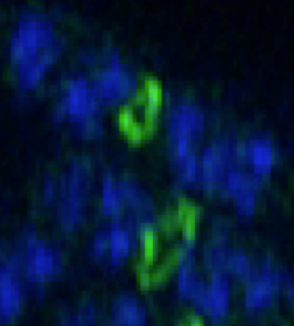

*Z-rings caught in the act. Super-resolution fluorescence of two E. coli cells at
different stages of constriction, with FtsZ in green marking the division plane.*

<sub>Figure: [Zrings.png](https://en.wikipedia.org/wiki/FtsZ#/media/File:Zrings.png) by Hazelsplace, Wikimedia Commons, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). Unmodified.</sub>

Everything below is anchored on **1FSZ**, FtsZ from the archaeon *Methanocaldococcus
jannaschii*. Why this one:

- **Two clear domains** in a 372-residue construct: an N-terminal GTPase core (roughly
  23-190) and a C-terminal domain (roughly 190-356). Good for domain-level thinking.
- **Bound GDP** resolved in the crystal. FtsZ is a GTPase and this is its real nucleotide,
  not a crystallization artifact.
- The crystal resolved only residues **23-356**. The 38 residues at the two ends were never
  modeled, and there are no internal gaps. Keep that number for the B-factor section.


### The PDB, and why programmatic access matters

You met the PDB in the lectures. What matters here is the **access pattern**.

You cannot click through 250 entries one at a time and keep the comparison consistent. The
Search API lets you send one JSON query over HTTP and get every matching structure back as
structured JSON, ready to filter, sort and tabulate. The shape is always **submit a query,
get JSON back, parse it in code**, and you will meet it again later in this notebook, searching a
sequence database on EBI's servers. It is how you talk to any large database, not a PDB trick.

We use `requests` directly, and **BioPandas** later loads one structure's coordinates
into a DataFrame.

[PDB Search API docs](https://search.rcsb.org/index.html#search-api) ·
[worked examples](https://search.rcsb.org/index.html#examples)

### 1. The protein, and every structure of its family

Everything starts from the **protein**, not from one crystal of it. RCSB records which
UniProt entry each chain belongs to, and much more: one request to its Data API returns the
chain's UniProt accession and sequence, how UniProt's numbering lines up with the file's,
and everything annotated along the chain (drawn in section 2). With the UniProt sequence we
then ask the PDB: "which structures in here look like this protein?" That gives the
family's structures, the experiments the field has run on this protein and its relatives.
1FSZ is one of them, and the question for this section is **where it sits among them**:
how it was solved, and how sharp it is compared with the rest.

| Helper | Gives you |
|---|---|
| `rcsb_chain(pdb_id, chain)` | the chain's UniProt accession and sequence, the UniProt-to-file numbering, and its annotations |
| `search_pdb(sequence)` | every PDB entry whose sequence matches, best match first |
| `structure_table(pdb_ids)` | method, resolution, R-free and deposition year of those entries |

In [3]:
CHAIN_QUERY = """query($entry: String!, $chain: String!) {
  polymer_entity_instance(entry_id: $entry, asym_id: $chain) {
    rcsb_polymer_entity_instance_container_identifiers { auth_to_entity_poly_seq_mapping }
    rcsb_polymer_instance_feature { type name provenance_source
                                    feature_positions { beg_seq_id end_seq_id } }
    polymer_entity {
      rcsb_polymer_entity_feature { type name provenance_source
                                    feature_positions { beg_seq_id end_seq_id } }
      rcsb_polymer_entity_align { reference_database_name reference_database_accession
        aligned_regions { entity_beg_seq_id ref_beg_seq_id length } }
      uniprots { rcsb_id rcsb_uniprot_protein { sequence }
                 rcsb_uniprot_feature { type name feature_positions { beg_seq_id end_seq_id } } }
} } }"""

# The annotation types kept, and what each one is. RCSB serves many more (validation
# scores per residue, hydropathy, disorder predictions); these are the ones drawn here.
KINDS = {"CATH": "domain", "SCOP": "domain", "ECOD": "domain", "Pfam": "domain",
         "HELIX_P": "helix", "SHEET": "strand",
         "BINDING_SITE": "binding site", "ACTIVE_SITE": "active site"}


def rcsb_chain(pdb_id: str, chain: str = "A") -> tuple[str, str, pd.Series, pd.DataFrame]:
    """Everything RCSB knows about one chain, from one GraphQL request.

    Returns the UniProt accession, the UniProt sequence, `to_structure` (a Series from
    UniProt position to the residue number the file uses: the two often differ, through a
    tag, a construct that starts mid-protein or the authors' own scheme), and a table of
    annotations, one row per annotated residue: its source (CATH, SCOPe, ECOD, Pfam,
    PROMOTIF for secondary structure, PDB, UniProt), its kind (domain, helix, strand,
    binding site, active site), its name, and the residue in the file's numbering.
    `chain` is the chain ID as the file writes it.
    """
    answer = requests.post("https://data.rcsb.org/graphql", json={
        "query": CHAIN_QUERY, "variables": {"entry": pdb_id, "chain": chain}})
    found = answer.json()["data"]["polymer_entity_instance"]
    entity = found["polymer_entity"]
    # The file's residue number for each position of the chain's sequence (1, 2, 3, ...)
    author = found["rcsb_polymer_entity_instance_container_identifiers"][
        "auth_to_entity_poly_seq_mapping"]
    in_file = pd.Series([int(n) for n in author], index=range(1, len(author) + 1))

    uniprot = next(a for a in entity["rcsb_polymer_entity_align"]
                   if a["reference_database_name"] == "UniProt")
    accession = uniprot["reference_database_accession"]
    to_structure = pd.Series({
        region["ref_beg_seq_id"] + k: in_file[region["entity_beg_seq_id"] + k]
        for region in uniprot["aligned_regions"] for k in range(region["length"])})
    record = next(u for u in entity["uniprots"] if u["rcsb_id"] == accession)

    # Chain and entity annotations count in sequence positions, UniProt's in UniProt
    # positions: each is turned into the file's numbering with its own map.
    annotated = [(f, in_file) for f in (found["rcsb_polymer_instance_feature"] or [])
                 + (entity["rcsb_polymer_entity_feature"] or [])]
    annotated += [(f, to_structure) for f in record["rcsb_uniprot_feature"] or []]
    rows = []
    for feature, numbering in annotated:
        if feature["type"] not in KINDS:
            continue
        residues = [int(numbering[position])
                    for span in feature["feature_positions"] or []
                    for position in range(span["beg_seq_id"],
                                          (span["end_seq_id"] or span["beg_seq_id"]) + 1)
                    if position in numbering.index]  # a single residue has no end
        name = feature["name"] or ""
        if KINDS[feature["type"]] == "domain" and residues:  # two domains can share a name
            name = f"{name} ({min(residues)}-{max(residues)})"
        rows += [{"source": feature.get("provenance_source") or "UniProt",
                  "kind": KINDS[feature["type"]], "name": name, "residue": residue}
                 for residue in residues]
    return accession, record["rcsb_uniprot_protein"]["sequence"], to_structure, pd.DataFrame(rows)


def search_pdb(sequence: str, identity_cutoff: float = 0.3) -> list[str]:
    """Every PDB entry whose sequence matches `sequence`, best match first."""
    query = {"type": "terminal", "service": "sequence",
             "parameters": {"evalue_cutoff": 1, "identity_cutoff": identity_cutoff,
                            "target": "pdb_protein_sequence", "value": sequence}}
    response = requests.post(
        "https://search.rcsb.org/rcsbsearch/v2/query",
        json={"query": query, "return_type": "entry",
              "request_options": {"return_all_hits": True,
                                  "sort": [{"sort_by": "score", "direction": "desc"}]}},
    )
    response.raise_for_status()
    return [hit["identifier"] for hit in response.json().get("result_set", [])]


def structure_table(pdb_ids: list[str]) -> pd.DataFrame:
    """Method, resolution, R-free and deposition year for each entry, one row per entry.

    RCSB's Data API speaks GraphQL: one query names the fields wanted, and answers for
    hundreds of entries at once instead of one request each. Not every method reports
    every number: NMR has no resolution, cryo-EM no R-free, and an integrative model (built
    from several kinds of data) neither, so those come back empty.
    """
    query = """query($ids: [String!]!) { entries(entry_ids: $ids) {
      rcsb_id rcsb_entry_info { experimental_method resolution_combined }
      refine { ls_R_factor_R_free } rcsb_accession_info { deposit_date } } }"""
    entries = []
    for start in range(0, len(pdb_ids), 500):  # a few hundred per request keeps it quick
        answer = requests.post("https://data.rcsb.org/graphql", json={
            "query": query, "variables": {"ids": pdb_ids[start:start + 500]}})
        entries += answer.json()["data"]["entries"]
    return pd.DataFrame([{
        "pdb_id": e["rcsb_id"],
        "method": e["rcsb_entry_info"]["experimental_method"],
        "resolution": (e["rcsb_entry_info"]["resolution_combined"] or [None])[0],
        "r_free": (e["refine"] or [{}])[0].get("ls_R_factor_R_free"),
        "year": int(e["rcsb_accession_info"]["deposit_date"][:4]),
    } for e in entries])

In [4]:
accession, query, to_structure, features = rcsb_chain("1FSZ", "A")
pdb_ids = search_pdb(query)
family = structure_table(pdb_ids)

print(f"1FSZ chain A is UniProt {accession}, {len(query)} residues")
print(f"Structures of the family in the PDB: {len(family)}")
family.head()

1FSZ chain A is UniProt Q57816, 364 residues
Structures of the family in the PDB: 253


,pdb_id,method,resolution,r_free,year
0,9WSD,EM,4.00,NaN,2025
1,9V7V,EM,3.60,NaN,2025
2,9LFX,X-ray,3.49,0.2708,2025
3,9ISK,EM,2.73,NaN,2024
4,8IBN,EM,3.03,NaN,2023


### Where 1FSZ sits among them

In [5]:
print(family["method"].value_counts().to_string(), "\n")

mine = family.set_index("pdb_id").loc["1FSZ"]
xray = family.loc[family["method"] == "X-ray", "resolution"].dropna()
print(f"1FSZ: {mine['method']}, {mine['resolution']:.2f} Å, R-free {mine['r_free']:.3f}, "
      f"deposited {mine['year']}")
print(f"{(xray < mine['resolution']).sum()} of the family's {len(xray)} X-ray structures "
      f"are sharper; their median is {xray.median():.2f} Å")

method
X-ray    248
EM         5 

1FSZ: X-ray, 2.80 Å, R-free 0.282, deposited 1997
232 of the family's 248 X-ray structures are sharper; their median is 2.04 Å


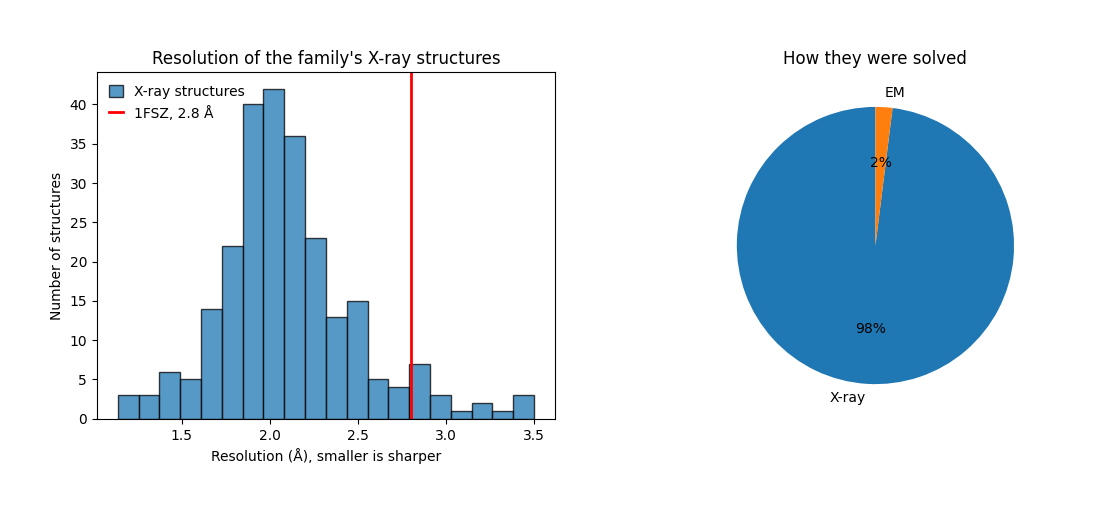

In [6]:
fig, (hist, pie) = plt.subplots(1, 2, figsize=(13, 4.5))

xray.plot.hist(ax=hist, bins=20, edgecolor="black", alpha=0.75, label="X-ray structures",
               title="Resolution of the family's X-ray structures")
hist.axvline(mine["resolution"], color="red", lw=2, label=f"1FSZ, {mine['resolution']:.1f} Å")
hist.set(xlabel="Resolution (Å), smaller is sharper", ylabel="Number of structures")
hist.legend()

family["method"].value_counts().plot.pie(ax=pie, autopct="%1.0f%%", startangle=90,
                                          title="How they were solved")
pie.set_ylabel("")
plt.show()

### 2. Visualization with py3Dmol

### The structure helpers

Four more functions, and the same rule as before: defined once here, called everywhere
below. These are the ones you will need again on your own protein.

| Helper | Gives you |
|---|---|
| `load_structure(pdb_id)` | protein atoms and heteroatoms, as two DataFrames |
| `heteroatom_inventory(hetatms)` | every non-protein species, with atom and copy counts |
| `bfactor_profile(atoms)` | CA B-factors indexed by residue, gaps included |
| `show_structure(pdb_id, ...)` | a py3Dmol cartoon: coloured along the chain or by B-factor, with named groups of residues, a ligand, or the pocket around it |

In [7]:
def load_structure(pdb_id: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Protein atoms and heteroatoms for one entry, as two DataFrames."""
    ppdb = PandasPdb().fetch_pdb(pdb_id)
    return ppdb.df["ATOM"], ppdb.df["HETATM"]


def heteroatom_inventory(hetatms: pd.DataFrame) -> pd.DataFrame:
    """Every non-protein species in the file, with how many atoms and copies each has."""
    return (
        hetatms.groupby("residue_name")
        .agg(atoms=("atom_number", "size"), copies=("residue_number", "nunique"))
        .sort_values("atoms", ascending=False)
    )


def bfactor_profile(atoms: pd.DataFrame) -> pd.Series:
    """CA B-factors indexed by residue number.

    NaN wherever the crystal resolved nothing. Reindexing onto the full range is what
    makes matplotlib draw real gaps instead of joining a line straight across them.
    """
    ca = atoms[atoms["atom_name"] == "CA"]
    profile = (ca.set_index("residue_number")["b_factor"]
               .reindex(range(ca["residue_number"].min(), ca["residue_number"].max() + 1)))
    profile.index.name = "Residue number"
    return profile


def show_structure(pdb_id: str, color: str = "spectrum",
                   groups: dict[str, list[int]] | None = None,
                   highlight: list[int] | tuple[int, ...] = (),
                   ligand: str | None = None, pocket_of: str | None = None,
                   label_pocket: bool = True, radius: float = 4.0,
                   width: int = 800, height: int = 500) -> py3Dmol.view:
    """Cartoon view of an entry.

    `color` is "spectrum" (along the chain, N-terminus blue to C-terminus red) or
    "b-factor" (rigid blue to flexible red). `groups` names sets of residues, each drawn in
    its own colour on grey, with the key printed. `highlight` colours those residues red;
    `ligand` shows a heteroatom as sticks; `pocket_of` asks the viewer itself for the
    residues lining that heteroatom, with `within` and `byres`, the same two words PyMOL
    uses. `hetflag` keeps the ligand and the waters out of the answer.
    """
    view = py3Dmol.view(query=f"pdb:{pdb_id}", width=width, height=height)
    if color == "b-factor":
        # Colour between the 5th and 95th percentile, so a few extreme atoms do not
        # wash everything else out. The range runs high to low: 3Dmol's red-white-blue
        # gradient starts red at its first value.
        atoms, _ = load_structure(pdb_id)
        low, high = atoms["b_factor"].quantile([0.05, 0.95])
        view.setStyle({"cartoon": {"colorscheme": {
            "prop": "b", "gradient": "rwb", "min": high, "max": low}}})
    elif groups or len(highlight) or pocket_of:
        view.setStyle({"cartoon": {"color": "lightgrey"}})
    else:
        view.setStyle({"cartoon": {"color": "spectrum"}})
    palette = ["crimson", "gold", "royalblue", "seagreen", "darkorange", "purple"]
    for (name, residues), colour in zip((groups or {}).items(), palette):
        view.addStyle({"resi": list(residues)}, {"cartoon": {"color": colour}})
        print(f"{colour:>11}: {name} ({len(residues)} residues)")
    if len(highlight):
        view.addStyle({"resi": list(highlight)}, {"cartoon": {"color": "red"}})
        view.addStyle({"resi": list(highlight)}, {"stick": {"color": "red"}})
    if pocket_of:
        pocket = {"hetflag": False, "byres": True,
                  "within": {"distance": radius, "sel": {"resn": pocket_of}}}
        view.addStyle(pocket, {"stick": {"colorscheme": "redCarbon"}})
        if label_pocket:
            view.addResLabels(pocket, {"font": "Arial", "fontSize": 10,
                                       "fontColor": "black", "showBackground": False})
    if ligand:
        view.addStyle({"resn": ligand}, {"stick": {"colorscheme": "greenCarbon"}})
    if pocket_of:
        view.zoomTo({"resn": pocket_of})
    else:
        view.zoomTo()
    return view

In [8]:
# The structure we are studying, coloured from N-terminus (blue) to C-terminus (red).
show_structure("1FSZ").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### What is known about this chain, drawn on 1FSZ

`rcsb_chain` already brought back everything annotated along 1FSZ's chain, each note with
its source: domains as CATH, SCOPe, ECOD and Pfam cut them, the helices and strands
PROMOTIF assigns from this very structure, the residues the PDB finds around the bound
GDP, and the sites UniProt records. All of it is in 1FSZ's own residue numbers, so it can
be drawn directly.

In [9]:
features.groupby(["kind", "source", "name"])["residue"].agg(["count", "min", "max"])

count  \
kind         source   name                                                        
binding site PDB      ligand GDP                                             14   
             UniProt                                                         11   
domain       CATH     Tubulin/FtsZ, C-terminal domain (250-356)             107   
                      Tubulin/FtsZ, GTPase domain (38-249)                  212   
             ECOD     Pkinase (232-354)                                     123   
                      Ras (23-231)                                          209   
             Pfam     FtsZ family, C-terminal domain (FtsZ_C) (247-341)      95   
                      Tubulin/FtsZ family, GTPase domain (Tubulin) (3...    162   
             SCOPe    Cell-division protein FtsZ (23-231)                   209   
                      Cell-division protein FtsZ (232-356)                  125   
helix        PROMOTIF helix                                                 146   
strand       PROMOTIF sheet                                                  75   

                                                                          min  \
kind         source   name                                                      
binding site PDB      ligand GDP                                           46   
             UniProt                                                       47   
domain       CATH     Tubulin/FtsZ, C-terminal domain (250-356)           250   
                      Tubulin/FtsZ, GTPase domain (38-249)                 38   
             ECOD     Pkinase (232-354)                                   232   
                      Ras (23-231)                                         23   
             Pfam     FtsZ family, C-terminal domain (FtsZ_C) (247-341)   247   
                      Tubulin/FtsZ family, GTPase domain (Tubulin) (3...   39   
             SCOPe    Cell-division protein FtsZ (23-231)                  23   
                      Cell-division protein FtsZ (232-356)                232   
helix        PROMOTIF helix                                                24   
strand       PROMOTIF sheet                                                40   

                                                                          max  
kind         source   name                                                     
binding site PDB      ligand GDP                                          212  
             UniProt                                                      212  
domain       CATH     Tubulin/FtsZ, C-terminal domain (250-356)           356  
                      Tubulin/FtsZ, GTPase domain (38-249)                249  
             ECOD     Pkinase (232-354)                                   354  
                      Ras (23-231)                                        231  
             Pfam     FtsZ family, C-terminal domain (FtsZ_C) (247-341)   341  
                      Tubulin/FtsZ family, GTPase domain (Tubulin) (3...  200  
             SCOPe    Cell-division protein FtsZ (23-231)                 231  
                      Cell-division protein FtsZ (232-356)                356  
helix        PROMOTIF helix                                               310  
strand       PROMOTIF sheet                                               353

**Secondary structure**, as PROMOTIF assigns it from this structure: helices and strands,
everything else grey.

In [10]:
shown = features[features["source"] == "PROMOTIF"]
kind = shown.groupby("kind")["residue"].apply(list)
show_structure("1FSZ", groups={"helix": kind["helix"], "strand": kind["strand"]}).show()

    crimson: helix (146 residues)
       gold: strand (75 residues)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Domains.** CATH cuts FtsZ into two: the nucleotide-binding GTPase domain and a
C-terminal domain. The table above shows the other classifications cutting in slightly
different places; a domain boundary is a judgement, so always say whose you use.

In [11]:
cath = features[features["source"] == "CATH"].groupby("name")["residue"].apply(list)
show_structure("1FSZ", groups=cath.to_dict(), ligand="GDP").show()

    crimson: Tubulin/FtsZ, C-terminal domain (250-356) (107 residues)
       gold: Tubulin/FtsZ, GTPase domain (38-249) (212 residues)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**The sites.** UniProt marks eleven residues as binding GTP, from the papers on this
protein. Drawn with the GDP of the crystal, they close around the nucleotide.

In [12]:
gtp = features.query("source == 'UniProt' and kind == 'binding site'")["residue"].tolist()
show_structure("1FSZ", highlight=gtp, ligand="GDP").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### What else is in the crystal? Cataloguing the heteroatoms

A PDB entry is not just a protein. Everything that was in the crystal and could be
modelled into the density is in the file, recorded as `HETATM` rather than `ATOM`:
substrates, cofactors, metal ions, and — very often — molecules that have nothing to do
with the biology at all.

**This distinction is one of the most consequential things to get right about a
structure**, and it is easy to get wrong. Buffer components (HEPES, acetate), solvents
(glycerol, ethanol), cryoprotectants and crystallisation additives all appear in exactly
the same way as a real substrate. Nothing in the file marks which is which. A study that
docks against a cryoprotectant, or "discovers" a binding site that is really a buffer
molecule wedged in a surface cleft, is a study built on a misread `HETATM` record.

So before doing anything else with a structure, list what is actually in it.

In [13]:
pdb_id = "1FSZ"
atoms_df, hetatms = load_structure(pdb_id)

inventory = heteroatom_inventory(hetatms)
print(f"Heteroatom species in {pdb_id}:\n")
print(inventory.to_string())

Heteroatom species in 1FSZ:

              atoms  copies
residue_name               
HOH             116     116
GDP              28       1


**The whole of 1FSZ, classified:**

| Code | Atoms | What it is | Real, or experimental artifact? |
|---|---|---|---|
| `GDP` | 28, one copy | guanosine 5'-diphosphate | **the biological ligand.** FtsZ is a GTPase and this is its real nucleotide |
| `HOH` | 116 | water | **solvent.** Never the answer to "what does this protein bind" |

**How you know, without being told.** No single rule settles it. Applied to this GDP:

- **Look it up.** The RCSB entry names the ligand and the paper says what was studied. The
  reliable route; the rest are heuristics.
- **Where does it sit?** The view below answers it: 17 residues line it within 4 Å,
  including the glycine-rich `GLY130-GLY136`. That many specific contacts is not an accident. A cryoprotectant in a
  surface groove looks nothing like it.
- **Is it a lab reagent?** Glycerol, HEPES, MES, PEG, sulfate, acetate and DMSO come from
  the experiment. A guanine nucleotide does not.
- **Does it recur in relatives?** Guanine nucleotides appear across the FtsZ and tubulin
  family. A cofactor recurs; a cryoprotectant is one crystallisation's accident.
- **Occupancy and order.** One full, well-ordered copy. Partial occupancy and high
  B-factors point the other way.

**A clean entry does not make the question optional, only easy.** Many carry five or six
species where one is the biology and nothing marks which.


In [14]:
# Ask the viewer where the ligand sits. `within` picks the atoms closer than 4 Å to the
# GDP, `byres` widens each hit to its whole residue, and `hetflag: False` leaves the
# ligand itself and the waters out. PyMOL says the same thing in the same words.
show_structure("1FSZ", ligand="GDP", pocket_of="GDP", radius=4.0).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [15]:
# Seventeen labels, read off the view above and typed out. That is the whole method: a
# binding site is short enough to type, and typing it makes you look at each residue
# instead of at a number. Notice they come in four stretches that are far apart in the
# sequence and adjacent in space.
contacts = ["GLY46", "GLY47", "ALA48", "ASN51",
            "GLY130", "LEU131", "GLY133", "GLY134", "THR135", "GLY136",
            "PRO161", "GLU165", "ARG169",
            "PHE208", "ALA211", "ASP212", "LEU215"]

contact_resids = [int(name[3:]) for name in contacts]   # the numbers, for the comparison below

print(f"{len(contacts)} residues line the GDP: {', '.join(contacts)}")

17 residues line the GDP: GLY46, GLY47, ALA48, ASN51, GLY130, LEU131, GLY133, GLY134, THR135, GLY136, PRO161, GLU165, ARG169, PHE208, ALA211, ASP212, LEU215


That contact list is the **binding site**, read off a geometric selection rather than assumed. Keep
it: a real ligand sits in a pocket lined by many residues making specific contacts, and
you can now say concretely which ones. It is also the list to compare against the
conserved positions you compute further down — if evolution has conserved the residues
that touch the nucleotide, that is a strong, checkable signal that the site matters.

### 3. B-factor analysis: predict first, then plot

B-factors (temperature factors) indicate atomic mobility and flexibility in protein
structures. Let's analyze B-factor patterns to understand protein dynamics and identify
flexible regions.

**How you'd reason about this before plotting (a worked example of predict-first):**

UniProt marks eleven residues of FtsZ as binding GTP (the sites view above). Before
looking at any numbers, the biologically motivated prediction is: residues that hold the
nucleotide, each making a specific contact with it, should be **more rigid** (lower
B-factor) than the protein as a whole. A residue that moves freely cannot keep a specific
contact.

This is exactly the kind of prediction you should write down **before** running the plot
below, on your own protein, in the workbook. Being wrong is fine: the point is to have a
falsifiable guess on record before you see the answer.

Residue range: 23 to 356
Present: 334   Missing: 0

B-factor: mean 50.6, min 19.0, max 99.8 A^2
GTP-binding residues: mean 30.4 A^2, and 11 of 11 below the protein's mean


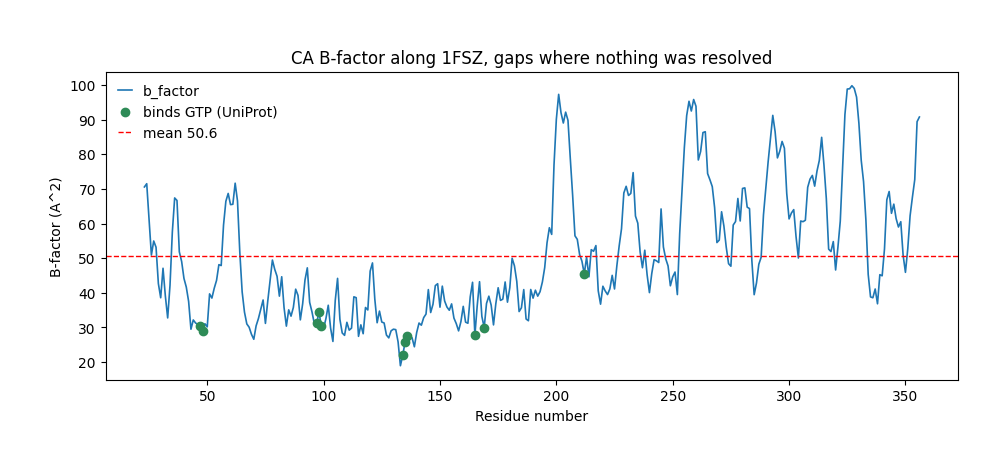

In [16]:
bfactors = bfactor_profile(atoms_df)
print(f"Residue range: {bfactors.index.min()} to {bfactors.index.max()}")
print(f"Present: {bfactors.notna().sum()}   Missing: {bfactors.isna().sum()}")
print(f"\nB-factor: mean {bfactors.mean():.1f}, min {bfactors.min():.1f}, "
      f"max {bfactors.max():.1f} A^2")
print(f"GTP-binding residues: mean {bfactors[gtp].mean():.1f} A^2, and "
      f"{(bfactors[gtp] < bfactors.mean()).sum()} of {len(gtp)} below the protein's mean")

ax = bfactors.plot(figsize=(11, 4), lw=1.2,
                   title=f"CA B-factor along {pdb_id}, gaps where nothing was resolved")
ax.scatter(gtp, bfactors[gtp], color="seagreen", zorder=3, label="binds GTP (UniProt)")
ax.set_ylabel("B-factor (A^2)")
ax.axhline(bfactors.mean(), color="red", ls="--", lw=1, label=f"mean {bfactors.mean():.1f}")
ax.legend()
plt.show()

**What this confirms:** the eleven GTP-binding residues average about 30 Å², against about
51 Å² for the rest of the protein, and every one of them sits below the protein's mean.
The prediction holds. Note also that the profile has **no internal gaps**: the 38
unresolved residues (22 N-terminal, 16 C-terminal) lie entirely outside the plotted range,
since residues 1-22 and 357-372 never appear in the file. You only notice they are missing
by comparing the modelled count (334) with the full construct (372).

The same numbers on the structure, from rigid blue to flexible red:

In [17]:
show_structure("1FSZ", color="b-factor", ligand="GDP").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---

## 4. Multiple sequence alignment: where is FtsZ conserved?

So far we've asked "how good is this structure?" Now a different question: "which *parts*
of it does evolution care most about?" A **multiple sequence alignment (MSA)** across many
relatives shows which positions stayed the same over large evolutionary distances. That is
a strong signal that a residue matters, whatever the quality of any one structure.

Building one takes four steps:

1. **Start from the protein, not the crystal.** The input is the protein's **UniProt**
   sequence, fetched in section 1. The PDB sequence is a construct: 1FSZ carries eight extra residues at its end,
   a histidine tag added to purify it, that no FtsZ in nature has.
2. **Find its relatives in a sequence database**: **Swiss-Prot**, the reviewed, manually
   annotated part of UniProt, searched with **phmmer** (HMMER package) on EBI's servers.
   phmmer turns the sequence into a profile HMM and scores every Swiss-Prot entry against it.
3. **Retrieve each relative's full sequence**, not only the stretch that matched.
4. **Align them all** with **FAMSA**, locally.

Why not collect relatives from the PDB, as in section 1? It holds about 250 FtsZ entries,
but grouped at 95% identity they are about fifteen distinct sequences.

Two more steps after the alignment. **Near-duplicates are removed**: Swiss-Prot holds the
same protein from many closely related species, and a pile of near-identical sequences
makes every column look conserved, so we keep **one representative of every group of
sequences at least 95% identical**. And conservation is **mapped back onto the structure**,
because UniProt and the PDB file need not number residues the same way; `to_structure`
from section 1 says how the two line up.

| Helper | Gives you |
|---|---|
| `hmmer_search(sequence)` | phmmer against Swiss-Prot: the full sequence of every significant hit |
| `align(sequences)` | the multiple sequence alignment, made with FAMSA |
| `drop_redundant(aligned, anchor)` | the anchor first, then one representative per group at least 95% identical |
| `conservation(aligned, anchor)` | per residue of the anchor: the fraction of sequences that keep its amino acid |
| `show_alignment(aligned, n_sequences)` | the first sequences of the alignment, over its whole length |

In [18]:
HMMER = "https://www.ebi.ac.uk/Tools/hmmer/api/v1"


def hmmer_search(sequence: str, database: str = "swissprot",
                 timeout: float = 600.0) -> dict[str, str]:
    """Search with phmmer at EBI: the full sequence of every significant hit, best first.

    Returns {UniProt entry name: full-length sequence}. Full length, not only the stretch
    that matched, because the alignment is built from whole proteins.
    """
    submitted = requests.post(f"{HMMER}/search/phmmer",
                              json={"input": f">query\n{sequence}", "database": database})
    submitted.raise_for_status()
    job = submitted.json()["id"]
    deadline = time.time() + timeout

    # 1. Ask until the search is done. A busy server can briefly answer with an error
    #    page instead of a status; that just means "ask again".
    status = None
    while status != "SUCCESS":
        if status == "FAILURE" or time.time() > deadline:
            raise RuntimeError(f"phmmer job {job} did not finish (last status: {status})")
        time.sleep(2)
        answer = requests.get(f"{HMMER}/result/{job}", params={"page_size": 1})
        status = answer.json().get("status") if answer.ok else None
    if answer.json()["result"]["stats"]["nincluded"] == 0:
        return {}

    # 2. The file of full-length hits is made on request: ask for it, then fetch it
    #    until it exists.
    requests.post(f"{HMMER}/download/{job}/fullfasta")
    while not (download := requests.get(f"{HMMER}/download/{job}/fullfasta")).ok:
        if time.time() > deadline:
            raise RuntimeError(f"no sequence file for phmmer job {job}")
        time.sleep(2)
    fasta = gzip.decompress(download.content).decode()
    return {rec.id: str(rec.seq) for rec in SeqIO.parse(io.StringIO(fasta), "fasta")}


def align(sequences: dict[str, str]) -> dict[str, str]:
    """A multiple sequence alignment of `sequences`, made locally with FAMSA.

    FAMSA returns the rows in its own order; they are put back in the order given.
    """
    msa = Aligner(guide_tree="upgma").align(
        [Sequence(name.encode(), seq.encode()) for name, seq in sequences.items()])
    rows = {row.id.decode(): row.sequence.decode() for row in msa}
    return {name: rows[name] for name in sequences}


def drop_redundant(aligned: dict[str, str], anchor: str,
                   max_identity: float = 0.95) -> dict[str, str]:
    """`anchor` first, then one representative per group of near-identical sequences.

    The others are taken in the order given (best hit first) and each is kept only if it
    is less than `max_identity` identical to every sequence kept so far, so a group is
    represented by its best match. Identity is counted over the anchor's residues, at the
    positions where both sequences have one.
    """
    names = [anchor, *(name for name in aligned if name != anchor)]
    columns = [col for col, char in enumerate(aligned[anchor]) if char != "-"]
    rows = np.array([[aligned[name][col] for col in columns] for name in names])
    has_residue = rows != "-"
    kept = [0]
    for i in range(1, len(rows)):
        both = has_residue[kept] & has_residue[i]
        same = (rows[kept] == rows[i]) & both
        identity = same.sum(axis=1) / np.maximum(both.sum(axis=1), 1)
        if identity.max() < max_identity:
            kept.append(i)
    return {names[i]: aligned[names[i]] for i in kept}


def conservation(aligned: dict[str, str], anchor: str) -> pd.Series:
    """Per residue of the anchor: the fraction of sequences carrying the same amino acid.

    Indexed by the anchor's own numbering (1 = its first residue), which for a UniProt
    sequence is UniProt numbering. A gap counts as not keeping the residue.
    """
    columns = [col for col, char in enumerate(aligned[anchor]) if char != "-"]
    rows = np.array([[row[col] for col in columns] for row in aligned.values()])
    anchor_row = np.array([aligned[anchor][col] for col in columns])
    kept = (rows == anchor_row).mean(axis=0)
    return pd.Series(kept, index=range(1, len(columns) + 1), name="conservation")


def show_alignment(aligned: dict[str, str], n_sequences: int = 10) -> None:
    """Draw the first `n_sequences` of the alignment over its whole length, letters and all.

    Columns where none of them has a residue belong to other sequences' insertions and are
    left out. The bar underneath is the consensus of the rows drawn.
    """
    shown = dict(list(aligned.items())[:n_sequences])
    rows = np.array([list(seq) for seq in shown.values()])
    rows = rows[:, (rows != "-").any(axis=0)]
    records = [SeqRecord(Seq("".join(row)), id=name, description="")
               for name, row in zip(shown, rows)]
    MsaViz(MultipleSeqAlignment(records), color_scheme="Clustal", wrap_length=80,
           show_grid=True, show_consensus=True).plotfig(dpi=72)

In [19]:
relatives = hmmer_search(query)
aligned = drop_redundant(align({accession: query, **relatives}), anchor=accession)

print(f"1FSZ chain A is UniProt {accession}, {len(query)} residues; the structure holds "
      f"UniProt {to_structure.index.min()}-{to_structure.index.max()}")
print(f"Swiss-Prot relatives, full length: {len(relatives)}")
print(f"Alignment: {len(aligned[accession])} columns")
print(f"After grouping at 95%: {len(aligned) - 1} relatives, plus {accession} itself")

1FSZ chain A is UniProt Q57816, 364 residues; the structure holds UniProt 1-364
Swiss-Prot relatives, full length: 165
Alignment: 1282 columns
After grouping at 95%: 107 relatives, plus Q57816 itself


**Who came back?** Each relative is named by its UniProt entry name, `MNEMONIC_SPECIES`, and
the mnemonic says what the protein is: `FTSZ` is FtsZ, `TBA` and `TBB` are α- and
β-tubulin, `CETZ` is a tubulin-like protein of archaea. So you can read the alignment's membership rather than trust it.

In [20]:
# FTSZ1_METJA is the mnemonic FTSZ1 plus a species code; drop the digits to group them.
mnemonic = pd.Series([name.split("_")[0].rstrip("0123456789") for name in list(aligned)[1:]])
mnemonic.value_counts().head(12)

FTSZ     63
TBA      18
CETZ     11
TBB       6
FTZ       2
FTSZA     1
FTSZL     1
FTSZB     1
TBAN      1
TUBZ      1
ARC       1
TBAE      1
Name: count, dtype: int64

**38 of the 107 relatives are tubulins or tubulin-like, and they stay.** FtsZ and tubulin
share the GTPase domain that binds the nucleotide, and phmmer finds the relationship even
though a tubulin is only about a sixth identical to FtsZ across the whole alignment
(median 16%). They are not contamination. They are the distant relatives that make
conservation informative: whatever survives across *both* families is what the shared
fold cannot do without.

### Conservation, residue by residue

`conservation` numbers residues the UniProt way; `to_structure` turns each UniProt position
into the residue number the 1FSZ file uses, and keeps only the positions the construct
contains. For 1FSZ the two numberings happen to agree. For many proteins they do not.

**The cutoff: the most conserved tenth of the protein.** A fixed identity cutoff means
something different in every family. Across FtsZ *and* tubulin only a handful of residues
are still identical in 90% of the sequences, while a family without distant relatives
would pass dozens. Calling the top 10% "conserved" asks the same question of every
protein, and it makes the chance baseline simple: a residue picked at random has a 10%
chance of being called conserved.

In [21]:
by_uniprot = conservation(aligned, accession)
in_structure = by_uniprot[by_uniprot.index.isin(to_structure.index)]
in_structure.index = to_structure[in_structure.index].to_numpy()  # UniProt -> 1FSZ

# Only residues the crystal modelled can be drawn, so the cutoff is taken over those.
modelled = in_structure[in_structure.index.isin(atoms_df["residue_number"])]

CONSERVED_SHARE = 0.10  # the most conserved tenth of the modelled residues
cutoff = modelled.quantile(1 - CONSERVED_SHARE)
conserved = modelled[modelled >= cutoff]

print(f"{len(modelled)} modelled residues, {len(aligned)} sequences in the alignment")
print(f"Cutoff: kept by at least {cutoff:.0%} of the sequences -> "
      f"{len(conserved)} conserved residues")

334 modelled residues, 108 sequences in the alignment
Cutoff: kept by at least 71% of the sequences -> 35 conserved residues


In [22]:
# The 17 contacts typed out earlier, against the rate you would get by chance.
baseline = len(conserved) / len(modelled)
expected = baseline * len(contact_resids)
observed = len(set(contact_resids) & set(conserved.index))
print(f"Conserved GDP contacts: {observed} of {len(contact_resids)}; "
      f"by chance about {expected:.1f} ({observed / expected:.1f}x)")

residue = atoms_df.drop_duplicates("residue_number").set_index("residue_number")["residue_name"]
print("\nConserved residues:")
print(", ".join(f"{residue[r]}{r}" for r in conserved.index))

Conserved GDP contacts: 8 of 17; by chance about 1.8 (4.5x)

Conserved residues:
GLY47, GLY49, GLY63, ASN70, THR71, LEU76, GLY88, GLY94, GLY96, ALA97, GLY104, GLY130, GLY132, GLY133, GLY134, THR135, GLY136, GLY138, PRO141, GLY151, LEU153, PRO161, GLU165, ALA173, LEU180, ASP185, ASN192, LEU195, GLY230, ASN233, ASP235, GLY247, ASP294, GLY320, VAL333


Numbers are not an argument on their own. Look at the alignment itself. All of it is too
large to read (108 sequences, 1,282 columns), so `show_alignment` draws the first ten:
1FSZ's UniProt sequence and its nine closest relatives, over the whole length, letters and
all. Columns where none of the ten has a residue come from other sequences' insertions and
are left out.

Read down each column: where every sequence carries the same letter, evolution has not been
free to change it. Find the glycine-rich loop, `GGGTGTG`. The tubulins sit at the end of the
alignment; `show_alignment(dict(list(aligned.items())[-10:]))` draws the last ten instead.
The numbers along the bottom count the columns drawn, not residues of 1FSZ.

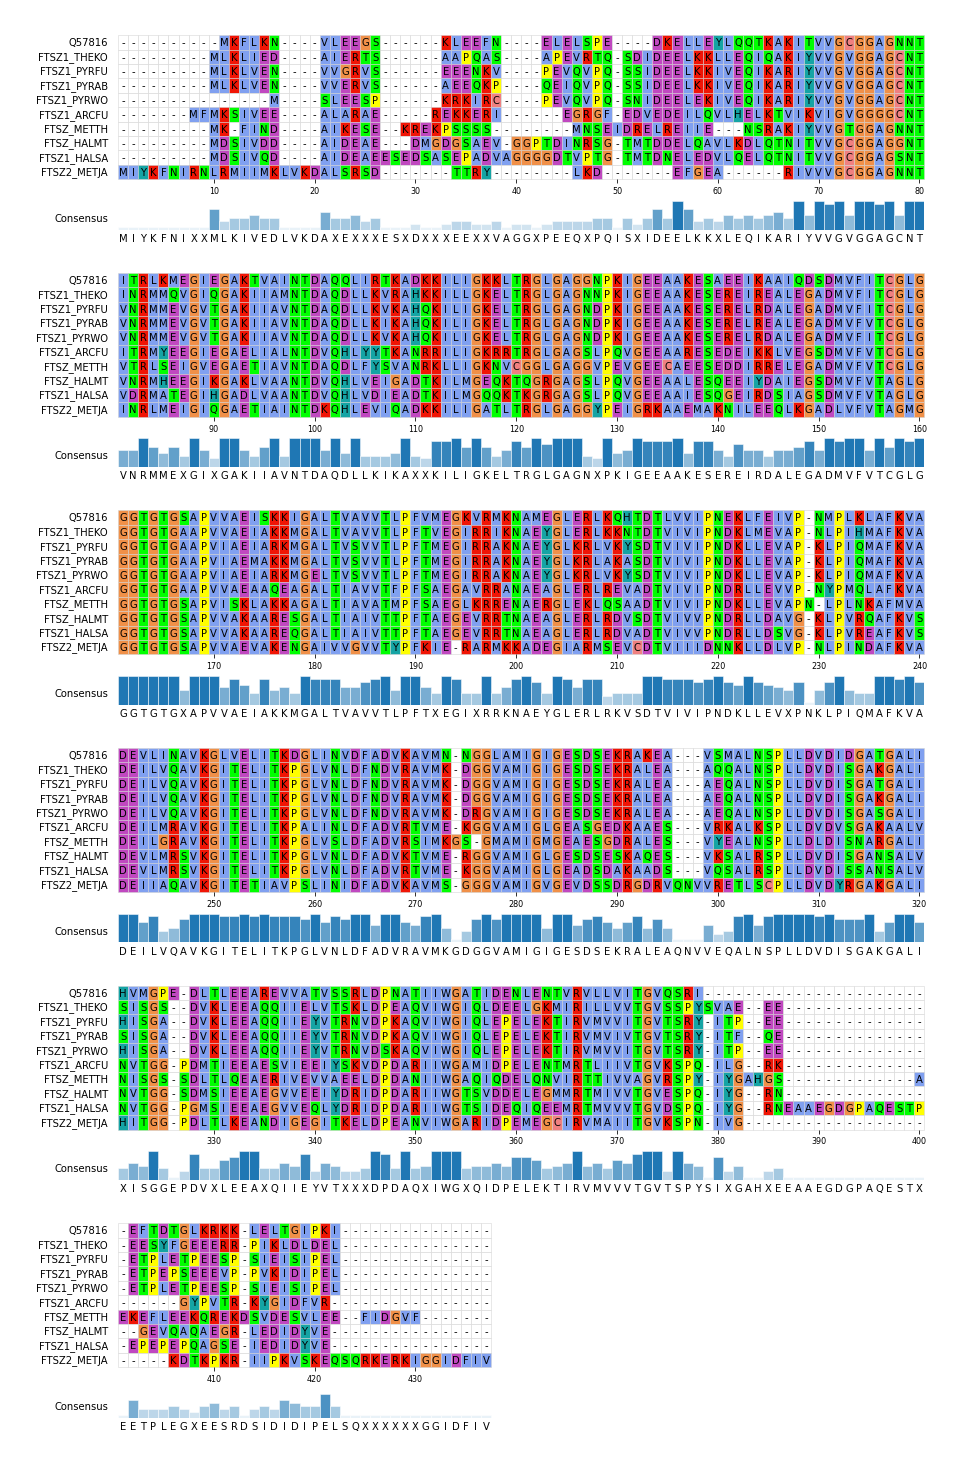

In [23]:
show_alignment(aligned)

In [24]:
show_structure("1FSZ", highlight=conserved.index.tolist(), ligand="GDP").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Interpretation: the conservation sits on the nucleotide.**

**8 of the 17 contact residues** are conserved, where chance would give about 2. The
strongest are the ones FtsZ and tubulin both keep: `G133`–`G136` in the glycine-rich loop,
and `P161`, each in at least 90% of both families. That loop (`GGGTG`, read it in the alignment above) is the
nucleotide-binding signature of the tubulin/FtsZ family and the structural equivalent of
the P-loop in other GTPases. Glycine lets the backbone wrap tightly around the phosphates,
and almost any substitution would clash.

**Read the contacts that miss the cutoff one by one. Each says something different.**

- **`G46`, `N51`:** kept in 97% of FtsZ, but tubulins carry other amino acids there
  (isoleucine or valine for `G46`, aspartate or glutamate for `N51`), and a third of them
  have a gap. Conserved within FtsZ, not across the superfamily. Their neighbour `G47` is
  kept by a third of the tubulins too, and makes the cut.
- **`R169`, `F208`, `A211`, `D212`, `L215`:** the same story, more clearly: kept in 84–91%
  of FtsZ, while tubulin puts a glutamate, a tyrosine, a leucine, an asparagine and an
  isoleucine there. Keeping the tubulins is what separates family-specific positions from
  the shared core.
- **`A48`, `L131`:** these genuinely vary, even among FtsZ.

A gap and a substitution are different evidence. A gap can mean the relative truly lacks
the residue, or only that the aligner could not place it: check which before you believe a
low score.

**The cutoff is a choice, so report it.** A stricter `CONSERVED_SHARE` keeps only what both
families share; a looser one lets FtsZ-only positions in. Swiss-Prot on EBI's server is a
fixed release, so this alignment comes out the same until that release changes.

---

# End of the guide

That is the whole pipeline on 1FSZ: the protein and its family's structures →
visualization → B-factors → alignment → conservation on the structure.

**Now open `ex01_workbook.ipynb`.**